In [1]:
from collections import defaultdict
import toml
import datetime

import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import select
from sqlalchemy.orm import Session
from sqlalchemy import create_engine

from model import Round

config = toml.load(open('config.toml'))
connection_string = config['database']['prod_connection_string']
engine = create_engine(connection_string)

In [3]:
maps

defaultdict(int,
            {'Cyberiad': 2323,
             'MetaStation': 420,
             'CereStation': 327,
             'Delta': 551})

In [2]:
maps = defaultdict(int)
r_count = 0
with Session(engine) as session:
    for r in session.query(Round).all():
        maps[r.map_name] += 1
        r_count += 1


In [2]:


r_count = 0
total_count = 0

biohazards = dict()

with Session(engine) as session:
    for r in session.query(Round).all():
        if r.start_datetime >= datetime.datetime(2024, 5, 6):
            for feedback in r.feedbacks:
                if feedback.key_name.startswith("Blob"):
                    for biohazard_type, tally in feedback.items():
                        if biohazard_type not in biohazards:
                            biohazards[biohazard_type] = defaultdict(int)
                        biohazards[biohazard_type][feedback.key_name] += tally
                    r_count += 1


In [3]:
biohazards

{'Blob': defaultdict(int,
             {'Blob survives to normal round en': 12,
              'Blob nuclear victories': 8,
              'Blob dies normal end': 21,
              'Blob survives to admin round end': 1})}

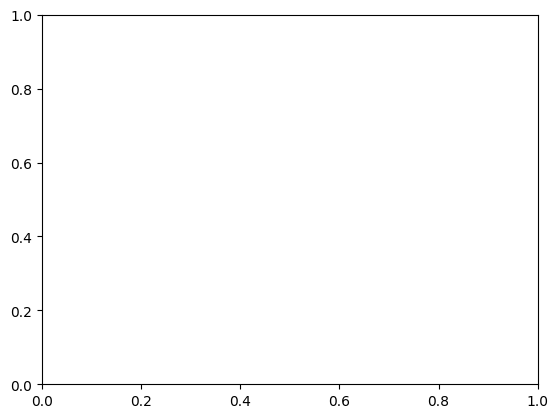

([<matplotlib.patches.Wedge at 0x15bbb6d8640>,
 [Text(0.6858387475358717, 0.8600146582346299, 'Blob survives to normal round en'),
  Text(-0.8063571273955388, 0.7481899378489496, 'Blob nuclear victories'),
  Text(-0.16394638125570124, -1.0877139256592978, 'Blob dies normal end'),
  Text(1.0969241854432237, -0.08220298893422683, 'Blob survives to admin round end')])

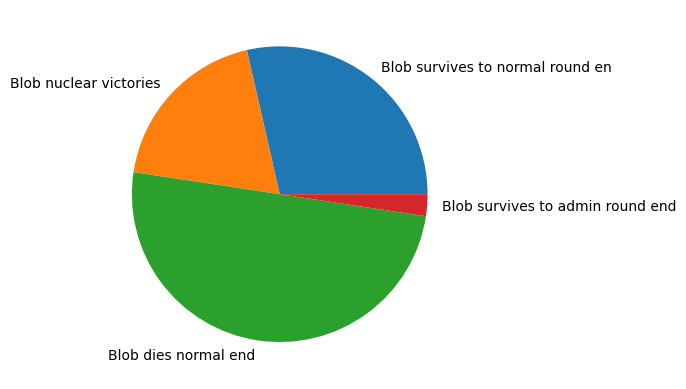

In [12]:
fig, ax = plt.subplots()
ax.pie(biohazards['Blob'].values(), labels=biohazards['Blob'].keys())

In [8]:
plt.show()